## Capstone Project -- IBM Attrition Data -- EDA (Exploratory Data Analysis)

*Load Required Packages and load the dataset*

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

**Basic Overview of the data -- Shape, Data Types, Preview**

In [3]:
# Shape -- (rows, columns)
print(df.shape)

(1470, 35)


In [4]:
# data types for each of the columns
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [5]:
# preview the data
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


**Summary Statistics**

In [6]:
# numeric features
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
# categorical features
df.describe(include = ['object'])

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


Only one value for "Over18" -- delete this column as it will not be informative

In [8]:
df.drop(columns = 'Over18', inplace = True)

**Target Variable Distribution** 

In [9]:
# Distribution of attrition
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

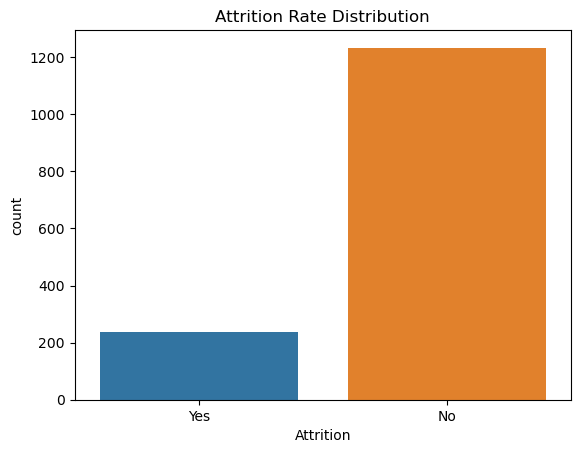

In [10]:
# Plot the values
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Rate Distribution")
plt.show()

**Correlation Analysis**

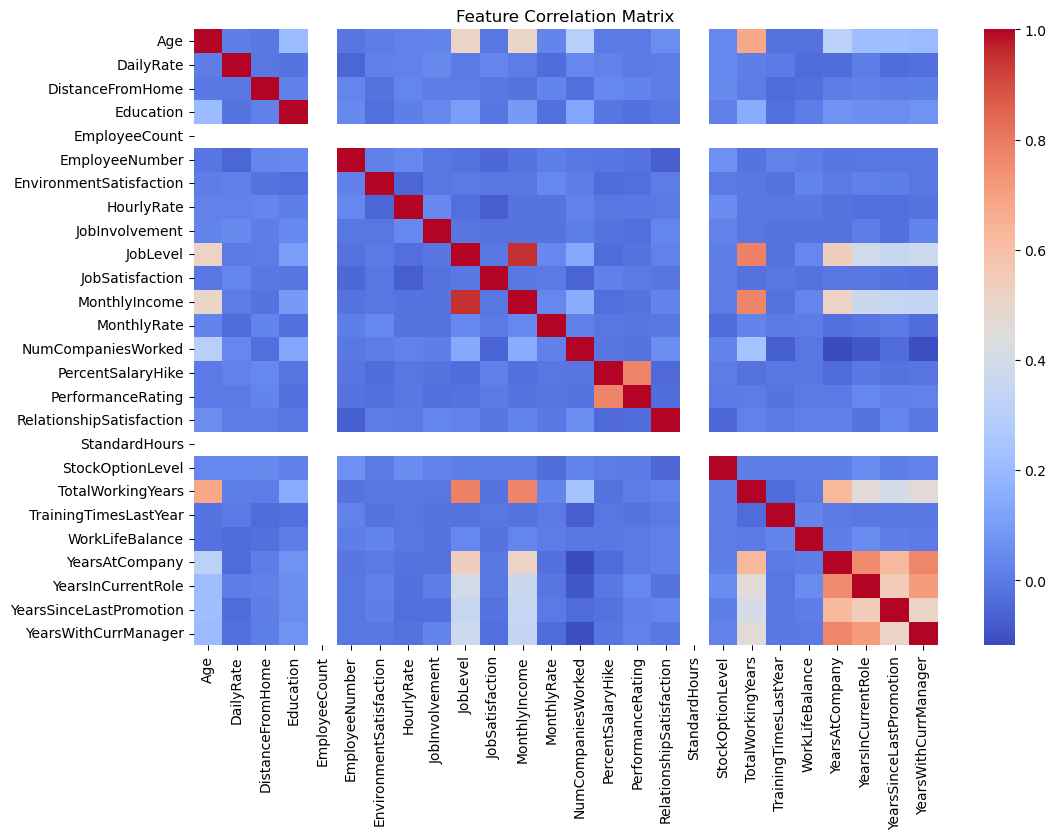

In [11]:
# Correlation Matrix -- Numeric Features Only

corr_matrix = df.corr(numeric_only = True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap = 'coolwarm', annot = False)
plt.title("Feature Correlation Matrix")
plt.show()


Takeaways from the above graphic:

- Older employees tend to have more experience, higher income, and higher job levels
- There are naturally correlated features -- YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager, YearsSinceLastPromotion
- Weak or Near-Zero Correlations -- DistanceFromHome, DailyRate, TrainingTimesLastYear, PerformanceRating
- Standard hours and employee counts are constant variables -- can drop these as they are not informative

In [12]:
df.drop(columns = ['StandardHours','EmployeeCount'], inplace = True)

In [13]:
# Correlation Table (Sorted) -- Correlations with Attrition
df['Attrition_n'] = df['Attrition'].map({'Yes':1, 'No':0})
correlations = df.corr(numeric_only=True)['Attrition_n'].drop('Attrition_n')
correlations.sort_values(ascending = False)

DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: Attrition_n, dtype: float64

Key Takeaway: None of the variables have a strong (greater than or equal to 0.7) correlation with attrition

**Sneak Peek at a few key relationships**

- In this context, the "key" relationships (Attrition versus Job Satisfaction, Monthly Income, and Age) were selected using semantics and gut-feelings

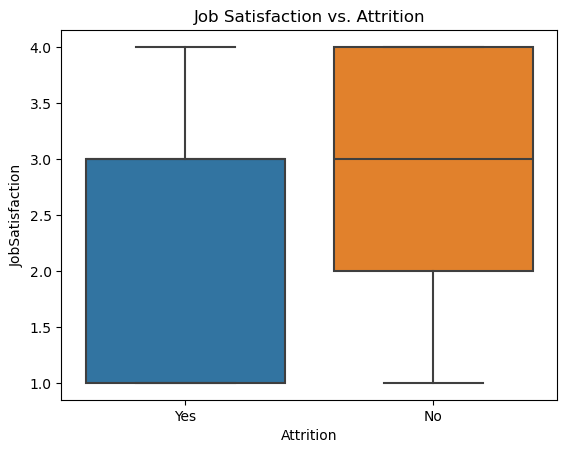

In [14]:
# Job Satistfaction vs. Attrition
sns.boxplot(x= 'Attrition', y = 'JobSatisfaction', data = df)
plt.title("Job Satisfaction vs. Attrition")
plt.show()

Takeaway from the above chart: There is a relationship between job satisfaction and attrition. The lower an employee's job satisfaction is, the more likely they are to leave the company. 

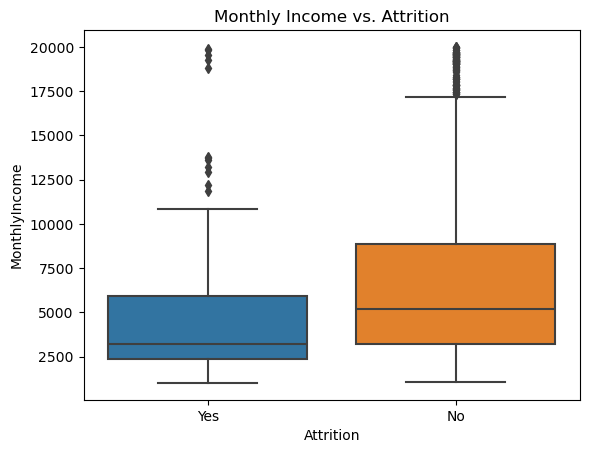

In [15]:
# Job Satistfaction vs. Attrition
sns.boxplot(x= 'Attrition', y = 'MonthlyIncome', data = df)
plt.title("Monthly Income vs. Attrition")
plt.show()

Takeaway from the above chart: Employee's with lower income are more likely to leave the organization. 

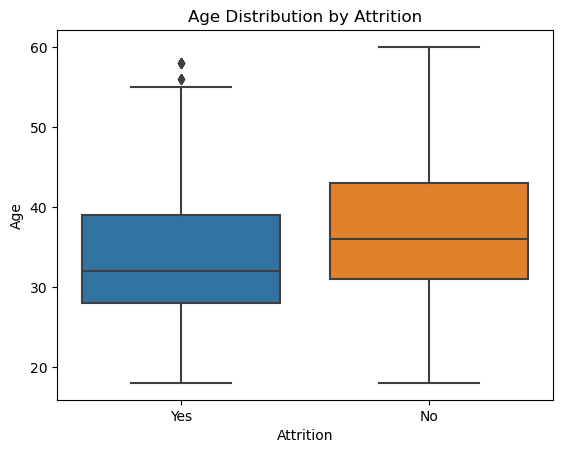

In [16]:
# Job Satistfaction vs. Attrition
sns.boxplot(x= 'Attrition', y = 'Age', data = df)
plt.title("Age Distribution by Attrition")
plt.show()

Takeaway from the above chart: Younger employees are more likely to leave the company.

**Categorical Variables -- Breakdown**

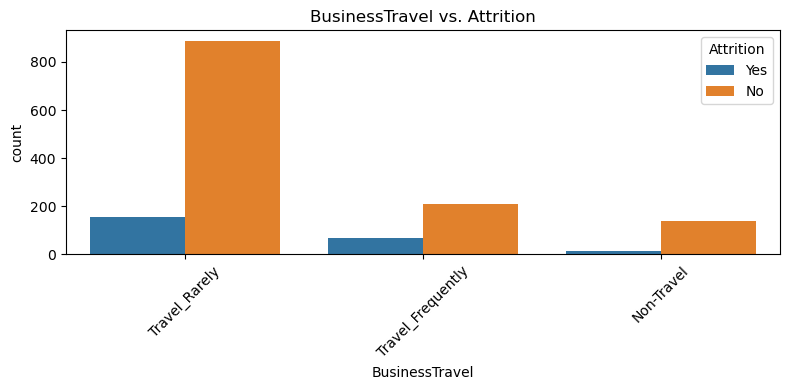

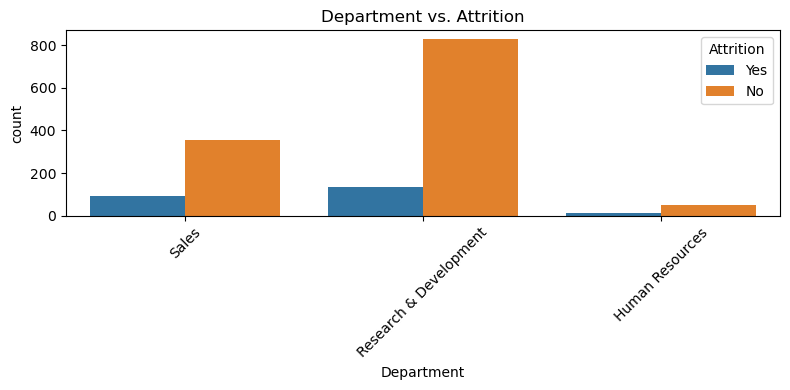

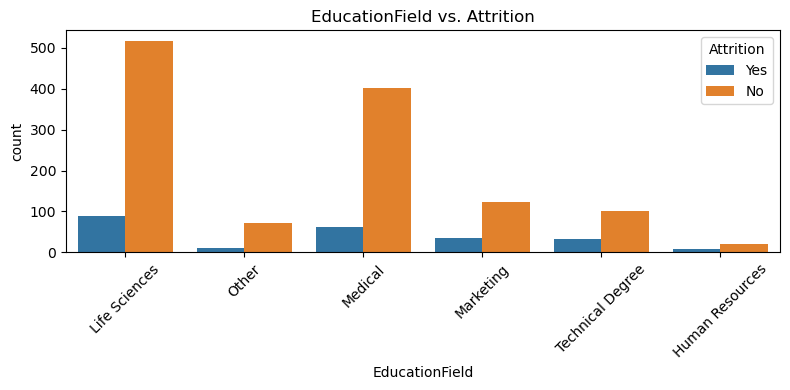

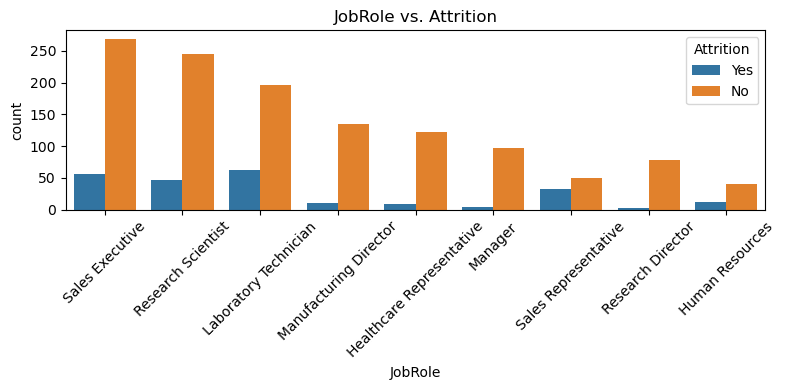

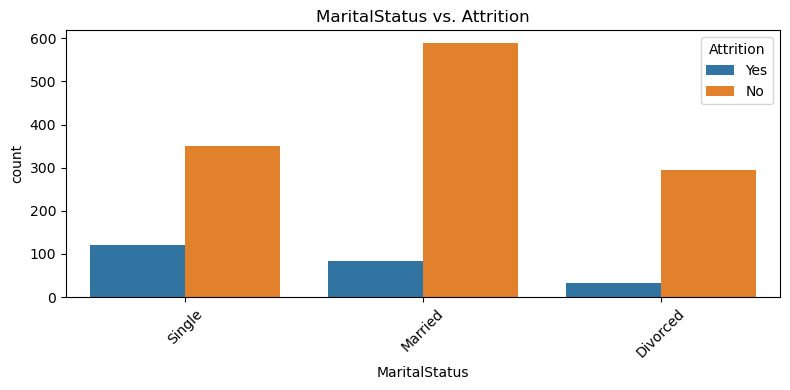

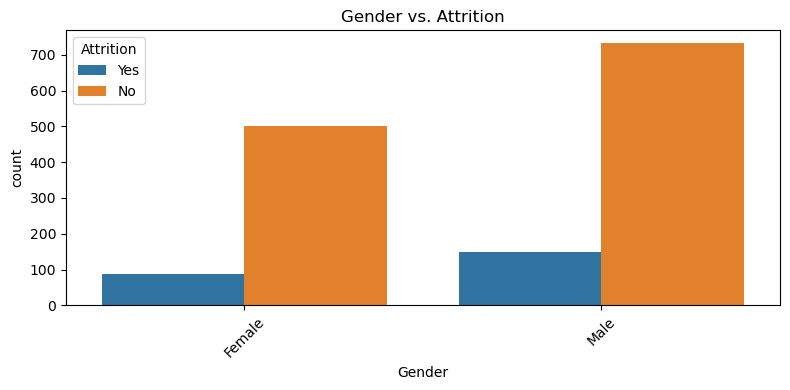

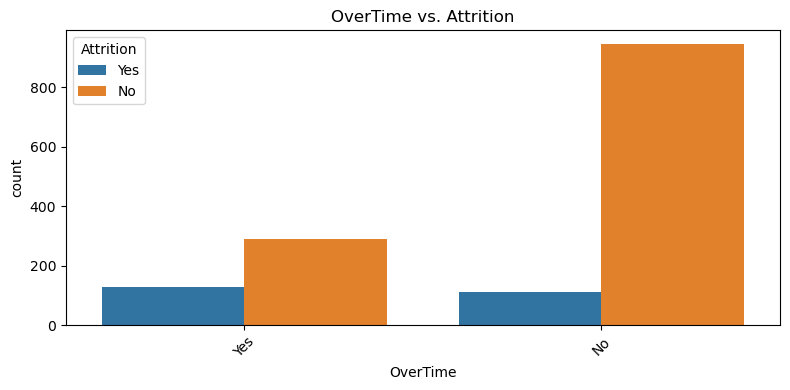

In [17]:
categorical_vars = ['BusinessTravel', 'Department', 'EducationField','JobRole', 'MaritalStatus','Gender', 'OverTime']

for var in categorical_vars:
    plt.figure(figsize=(8,4))
    sns.countplot(x=var, hue='Attrition', data=df)
    plt.title(f"{var} vs. Attrition")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

Key Takeaways from the above charts:
- Frequent Travelers have the highest attrition rates
- Attrition more common in sales than the other roles
- Sales Representatives and Lab Technicians have higher attrition rates
- Single employees have noticeably highe rattrition rates than the other employees (married, divorced)
- Employees that work overtime have a higher attrition rate than those who do not

**Everything above was accepted for the proposal -- do some additional cleansing below**

In [18]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_n
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,4,1,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,3,1,17,3,3,5,2,0,3,0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,1,1,9,5,3,7,7,1,7,0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,2,1,6,0,3,6,2,0,3,0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,4,0,17,3,2,9,6,0,8,0


In [19]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_n
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,0.161224
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,0.367863
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,0.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,1.000000


In [20]:
df["EmployeeNumber"]

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: EmployeeNumber, Length: 1470, dtype: int64

drop employee number as well -- will want to drop this as these are essentially employee ID numbers and will not be informative for this analysis

In [21]:
df.drop(columns = 'EmployeeNumber', inplace = True)

In [22]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_n
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,1,17,3,3,5,2,0,3,0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,1,1,9,5,3,7,7,1,7,0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,2,1,6,0,3,6,2,0,3,0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,4,0,17,3,2,9,6,0,8,0


Double check for missing values

In [23]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
Attrition_n                 0
dtype: int64

No Missing Values

*Convert attrition to a binary column*

In [24]:
df['Attrition'] = df['Attrition'].map({'Yes' : 1, 'No' : 0})

*The following are already ordinally encoded (they have a natural order to them)*:
- Education
    - 1 = below college
    - 2 = college
    - 3 = bachelor
    - 4 = master
    - 5 = doctor
- JobLevel
    - 1 = entry level
    - 2 = junior
    - 3 = mid level
    - 4 = senior
    - 5 = exec 
- EnvironmentSatisfaction
    - 1 = low
    - 2 = medium
    - 3 = high
    - 4 = very high
- JobSatisfaction
    - 1 = low
    - 2 = medium
    - 3 = high
    - 4 = very high 

*One-Hot Encode the following:*
- Department
- JobRole
- Gender
- MaritalStatus
- BusinessTravel
- EducationField
- OverTime

In [25]:
df = pd.get_dummies(df, columns = [
    'Department',
    'JobRole',
    'Gender',
    'MaritalStatus',
    'BusinessTravel',
    'EducationField',
    'OverTime'
], drop_first = True)

In [26]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,MaritalStatus_Married,MaritalStatus_Single,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,True,False,True,True,False,False,False,False,True
1,49,0,279,8,1,3,61,2,2,2,...,True,False,True,False,True,False,False,False,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,False,True,False,True,False,False,False,True,False,True
3,33,0,1392,3,4,4,56,3,1,3,...,True,False,True,False,True,False,False,False,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,41,4,2,4,...,True,False,True,False,False,False,True,False,False,False
1466,39,0,613,6,1,4,42,2,3,1,...,True,False,False,True,False,False,True,False,False,False
1467,27,0,155,4,3,2,87,4,2,2,...,True,False,False,True,True,False,False,False,False,True
1468,49,0,1023,2,3,4,63,2,2,2,...,True,False,True,False,False,False,True,False,False,False


Delete the "attrition_n" column created earlier that was used for mapping correlations to "attrition"

In [27]:
df.drop(columns = 'Attrition_n', inplace = True)

In [28]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,MaritalStatus_Married,MaritalStatus_Single,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,True,False,True,True,False,False,False,False,True
1,49,0,279,8,1,3,61,2,2,2,...,True,False,True,False,True,False,False,False,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,False,True,False,True,False,False,False,True,False,True
3,33,0,1392,3,4,4,56,3,1,3,...,True,False,True,False,True,False,False,False,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,41,4,2,4,...,True,False,True,False,False,False,True,False,False,False
1466,39,0,613,6,1,4,42,2,3,1,...,True,False,False,True,False,False,True,False,False,False
1467,27,0,155,4,3,2,87,4,2,2,...,True,False,False,True,True,False,False,False,False,True
1468,49,0,1023,2,3,4,63,2,2,2,...,True,False,True,False,False,False,True,False,False,False


**Separate into features and target**

In [29]:
y = df['Attrition']
X = df.drop(columns = ['Attrition'])

**Train and Test Split**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2,
    stratify = y # preserves the "Yes"/"No" ratio; keeps the same % of "Attrition = Yes" in both sets
)

**Class Imbalance Check**
- If "Yes" is much less than "No," consider:
    - Setting class-weight = 'balanced' in models like LogisitcRegression or RandomForest
    - Trying oversampling if needed

In [31]:
y_train.value_counts(normalize = True)

Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

"Yes" is much less as suggested above, so try class_weight = imbalanced when modeling below

**Feature Scaling (For Linear Models like logsitic regression and SVM)**

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**First/Baseline Model -- Logistic Regression**

In [33]:
# the parameter grid to search
param_grid = {
    'C' : [0.01, 0.1, 1, 10, 100], # regularization strength
    'penalty': ['l1', 'l2'], # regularization type
    'solver': ['liblinear', 'saga'], # solvers that support l1 and l2 penalties
    'class_weight': ['balanced'] # keep class weight balanced
}

# initialize logisitc regression model
lr = LogisticRegression(random_state = 10119371, max_iter = 1000)

# initalize grid search with 5-fold CV
grid_search = GridSearchCV(estimator = lr, param_grid = param_grid, cv = 5, scoring = 'roc_auc', n_jobs = -1, verbose = 1)

# fit to the training data
grid_search.fit(X_train_scaled, y_train)

# best parameters
best_lr = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}


In [34]:
# training
y_pred_train = best_lr.predict(X_train_scaled)
y_prob_train = best_lr.predict_proba(X_train_scaled)[:,1]
print("=== Logistic Regression -- Training Set ===")
print(classification_report(y_train, y_pred_train))
print("ROC-AUC:", roc_auc_score(y_train, y_prob_train))
print()



# testing
y_pred_test = best_lr.predict(X_test_scaled)
y_prob_test = best_lr.predict_proba(X_test_scaled)[:,1]
print("=== Logistic Regression -- Testing Set ===")
print(classification_report(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))

=== Logistic Regression -- Training Set ===
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       986
           1       0.41      0.79      0.54       190

    accuracy                           0.78      1176
   macro avg       0.68      0.79      0.70      1176
weighted avg       0.86      0.78      0.81      1176

ROC-AUC: 0.874410163339383

=== Logistic Regression -- Testing Set ===
              precision    recall  f1-score   support

           0       0.94      0.77      0.84       247
           1       0.37      0.72      0.49        47

    accuracy                           0.76       294
   macro avg       0.65      0.75      0.67       294
weighted avg       0.85      0.76      0.79       294

ROC-AUC: 0.8219484882418813


<Axes: title={'center': 'Logistic Regression Feature Importance'}>

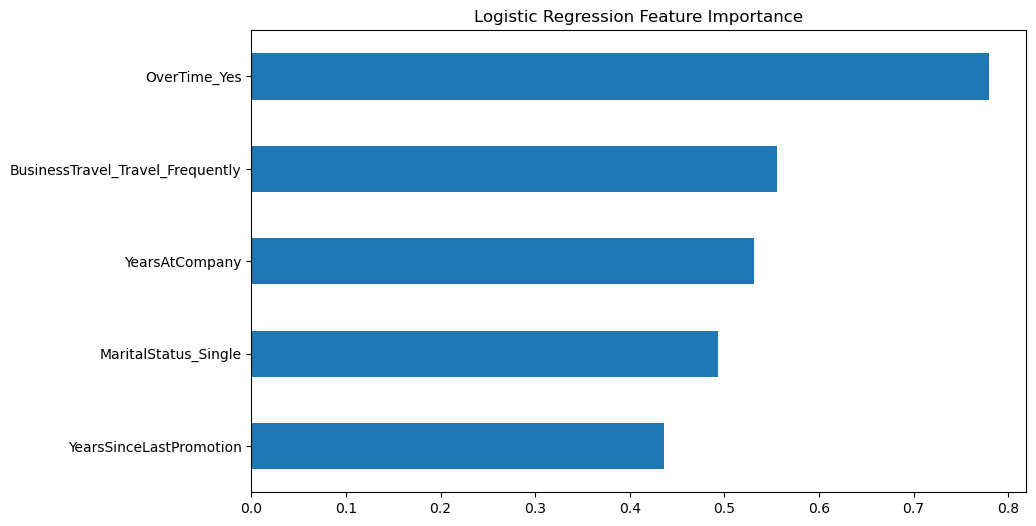

In [35]:
# Get the coefficients for all of the model's variables and then visualize the top 5
coeffs = pd.Series(best_lr.coef_[0], index = X.columns)
coeffs.abs().sort_values().tail(5).plot(kind = 'barh', figsize  =(10, 6), title = "Logistic Regression Feature Importance")

**Random Forest**

In [36]:
# the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4,6,8,None],
    'min_samples_leaf':[1,3,5],
    'max_features': ['sqrt','log2', None]
}

# initialize random forest model
rf = RandomForestClassifier(class_weight = 'balanced', random_state = 10119371) # might want to pick a random state for consistent results; look up "balanced" explanation again

# initalize grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    cv = 5, 
    scoring = 'roc_auc',
    n_jobs = -1,
    verbose = 1
)

# fit to the training data
grid_search.fit(X_train, y_train)

# best parameters
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 200}


In [37]:
# training
y_pred_train = best_rf.predict(X_train)
y_prob_train = best_rf.predict_proba(X_train)[:,1]
print("=== Random Forest -- Training ===")
print(classification_report(y_train, y_pred_train))
print("ROC_AUC: ", roc_auc_score(y_train, y_prob_train))
print()


# testing
y_pred_test = best_rf.predict(X_test)
y_prob_test = best_rf.predict_proba(X_test)[:,1]
print("=== Random Forest -- Testing ===")
print(classification_report(y_test, y_pred_test))
print("ROC_AUC: ", roc_auc_score(y_test, y_prob_test))

=== Random Forest -- Training ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

ROC_AUC:  1.0

=== Random Forest -- Testing ===
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.71      0.11      0.19        47

    accuracy                           0.85       294
   macro avg       0.78      0.55      0.55       294
weighted avg       0.83      0.85      0.80       294

ROC_AUC:  0.7834869497803428


<Axes: title={'center': 'Random Forest Feature Importance'}>

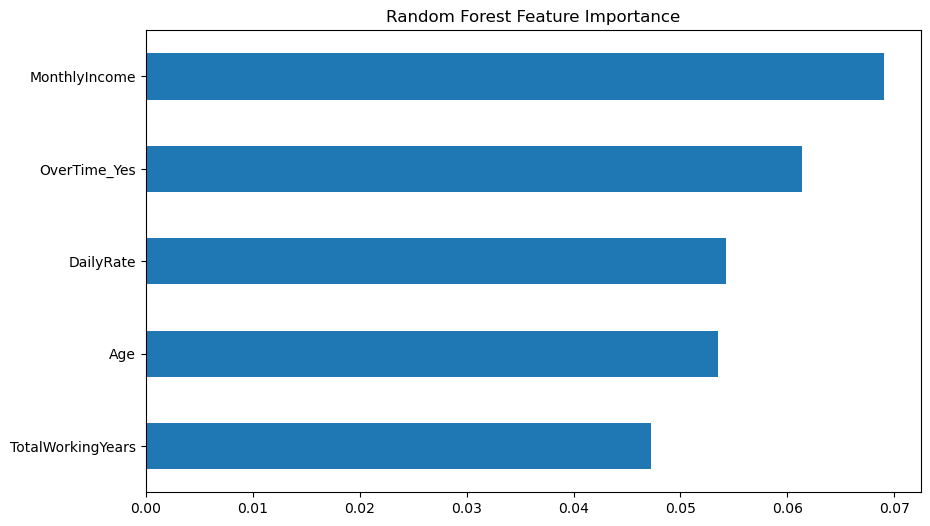

In [38]:
# Get the feature importance scores for all of the model's variables and then visualize the top 5

rf_importances = pd.Series(best_rf.feature_importances_, index = X.columns)
rf_importances.sort_values().tail(5).plot(kind = 'barh', figsize = (10, 6), title = "Random Forest Feature Importance")

**XGBoost**

In [39]:
# base model definition
xgb_base = xgb.XGBClassifier(
    use_label_encoder = False,
    objective = 'binary:logistic',
    eval_metric = 'logloss',
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), # handles imbalance,
    random_state = 10119371, 
    n_jobs = -1,
    verbosity = 0
) 

# the parameter grid to search
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [3,5,7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# initalize grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator = xgb_base, 
    param_grid = param_grid, 
    cv = 5, 
    scoring = 'roc_auc',
    verbose = 1, 
    n_jobs = -1
)

# fit to the training data
grid_search.fit(X_train, y_train)


# best parameters
best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [40]:
# Training
y_pred_train = best_xgb.predict(X_train)
y_prob_train = best_xgb.predict_proba(X_train)[:, 1]
print("=== XGBoost -- Training ===")
print(classification_report(y_train, y_pred_train))
print("ROC-AUC:", roc_auc_score(y_train, y_prob_train))

# Testing

y_pred_test = best_xgb.predict(X_test)
y_prob_test = best_xgb.predict_proba(X_test)[:, 1]
print("=== XGBoost -- Testing ===")
print(classification_report(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))

=== XGBoost -- Training ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

ROC-AUC: 1.0
=== XGBoost -- Testing ===
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       247
           1       0.59      0.40      0.48        47

    accuracy                           0.86       294
   macro avg       0.74      0.68      0.70       294
weighted avg       0.85      0.86      0.85       294

ROC-AUC: 0.8018778533896115


<Axes: title={'center': 'XGBoost Importance'}>

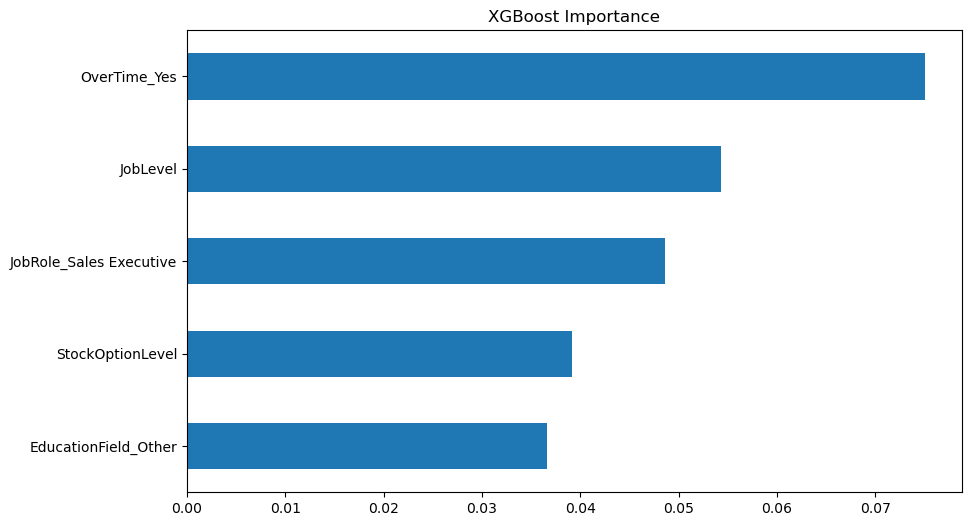

In [41]:
xgb_importances = pd.Series(best_xgb.feature_importances_, index = X.columns)
xgb_importances.sort_values().tail(5).plot(kind = 'barh', figsize = (10, 6), title = "XGBoost Importance")

**SMOTE + Random Forest**

In [42]:

# pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state = 10119371)),
    ('rf', RandomForestClassifier(random_state = 10119371))
])

# parameter grid ot search
param_grid = {
    'rf__n_estimators': [100,200],
    'rf__max_depth': [3,5,7],
    'rf__min_samples_leaf': [1,3,5],
    'rf__max_features': ['sqrt','log2']
}

# initalize grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    scoring = 'roc_auc',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

# fit to the original (not SMOTE) training set
grid_search.fit(X_train, y_train)

# best model and parameters
best_rf_smote = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'rf__max_depth': 7, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 3, 'rf__n_estimators': 200}


In [43]:
# training
y_pred_train = best_rf_smote.predict(X_train)
y_prob_train = best_rf_smote.predict_proba(X_train)[:, 1]
print("=== SMOTE + Random Forest -- Training ===")
print(classification_report(y_train, y_pred_train))
print("ROC-AUC: ", roc_auc_score(y_train, y_prob_train))
print()


# testing
y_pred_test = best_rf_smote.predict(X_test)
y_prob_test = best_rf_smote.predict_proba(X_test)[:, 1]
print("=== SMOTE + Random Forest -- Testing ===")
print(classification_report(y_test, y_pred_test))
print("ROC-AUC: ", roc_auc_score(y_test, y_prob_test))

=== SMOTE + Random Forest -- Training ===
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       986
           1       0.81      0.73      0.77       190

    accuracy                           0.93      1176
   macro avg       0.88      0.85      0.86      1176
weighted avg       0.93      0.93      0.93      1176

ROC-AUC:  0.9665688053805914

=== SMOTE + Random Forest -- Testing ===
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       247
           1       0.44      0.47      0.45        47

    accuracy                           0.82       294
   macro avg       0.67      0.68      0.67       294
weighted avg       0.82      0.82      0.82       294

ROC-AUC:  0.7783616159875959


<Axes: title={'center': 'Random Forest + SMOTE Feature Importance'}>

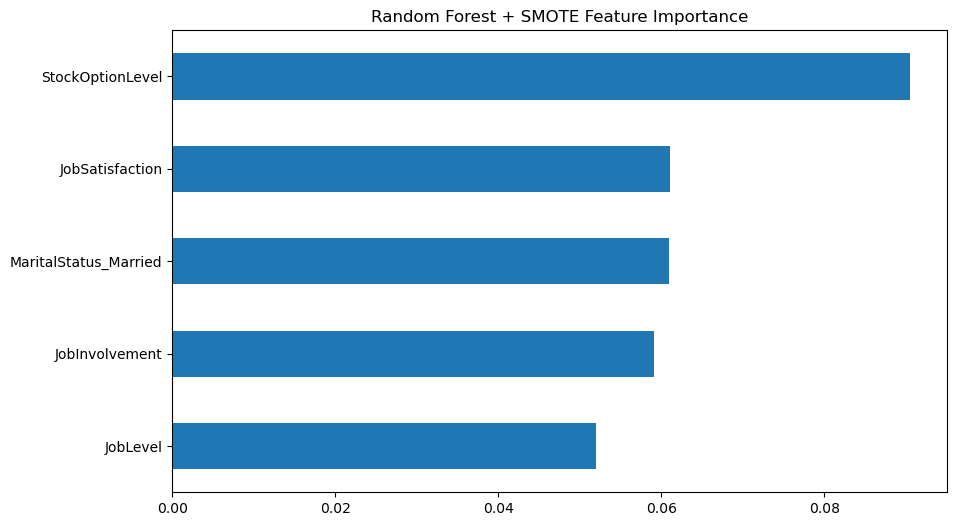

In [44]:
# Get the feature importance scores for all of the model's variables and then visualize the top 5

rf_model = best_rf_smote.named_steps['rf']
rf_importances = pd.Series(rf_model.feature_importances_, index = X.columns)
rf_importances.sort_values().tail(5).plot(kind = 'barh', figsize = (10, 6), title = "Random Forest + SMOTE Feature Importance")